In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/kaggle/input/unsupervised-learning-on-country-data/Country-data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [4]:
df.head(1)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553


In [5]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


### **Exploratory Data Analysis (EDA): Deep diving into child mortality, GDPP, and inflation to understand global disparitie**

In [6]:
import math
def plot_all_hist(df,title_prefix = ""):
    num_cols= df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols)/n_cols)
    plt.figure(figsize=(5*n_cols,4*n_rows))

    for i, col in enumerate(num_cols,1):
        plt.subplot(n_rows,n_cols,i)
        sns.histplot(df[col],kde=True,bins=30)
        plt.title(f"{title_prefix} {col}")
    plt.tight_layout()
    plt.show()

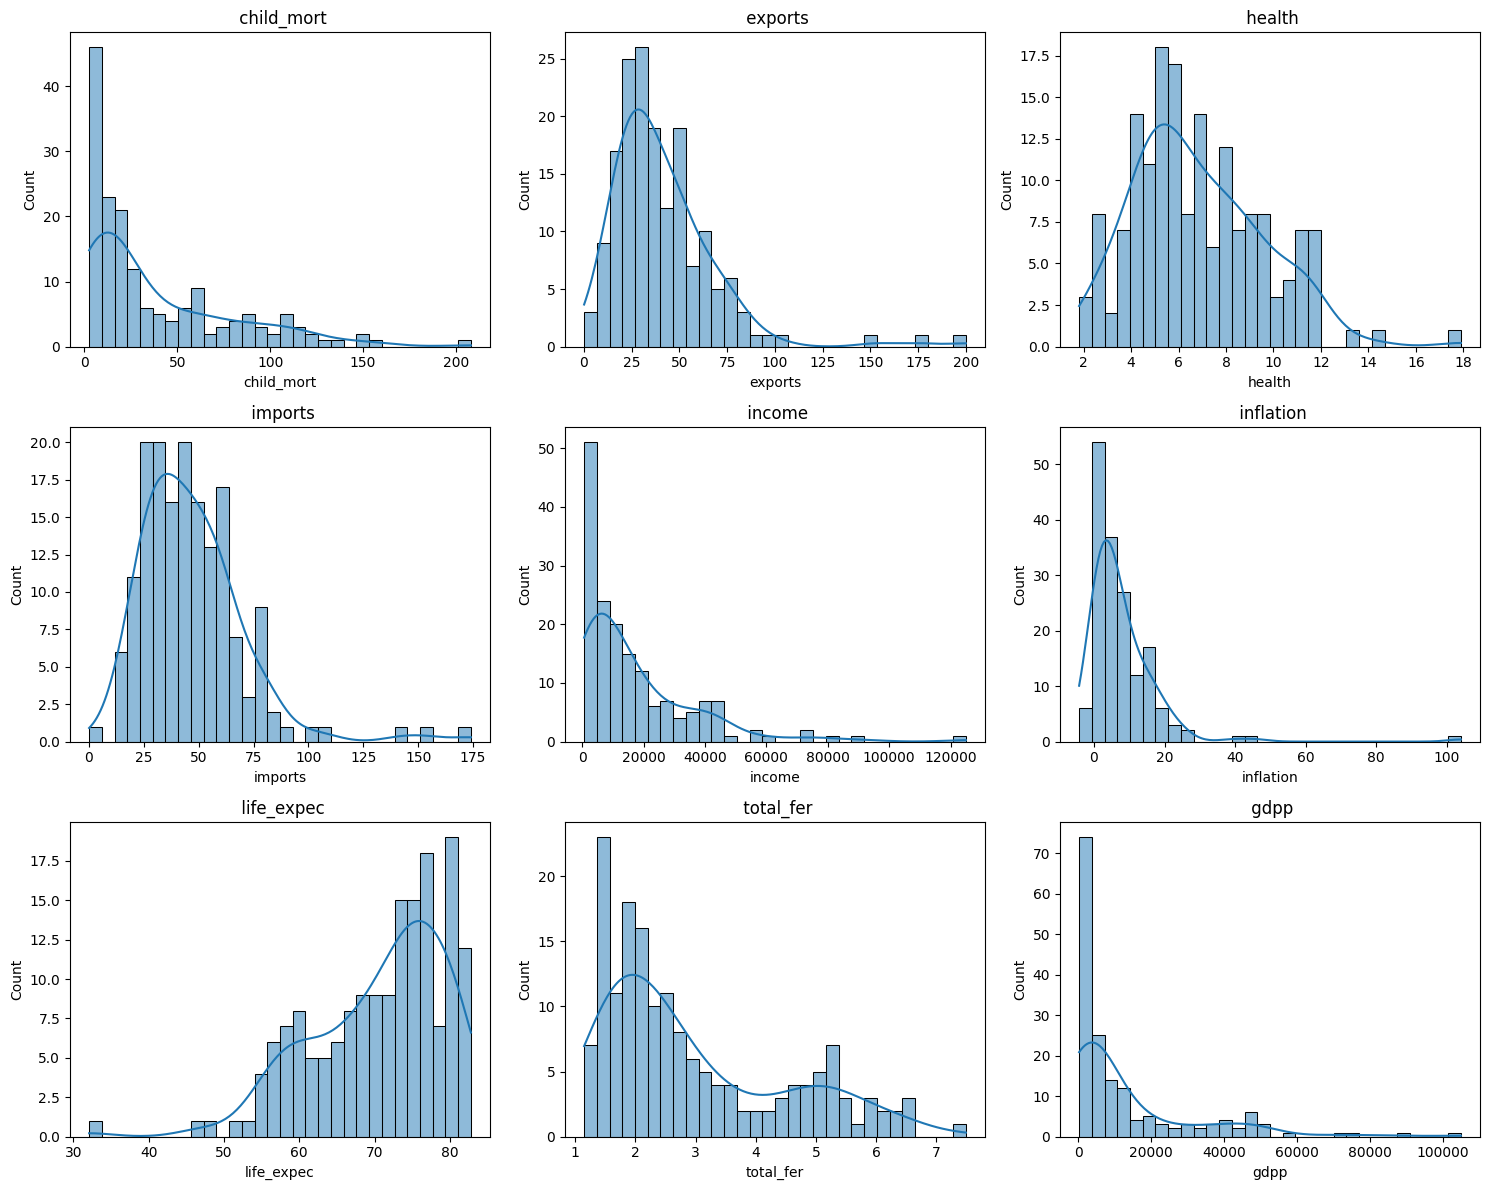

In [7]:
plot_all_hist(df)

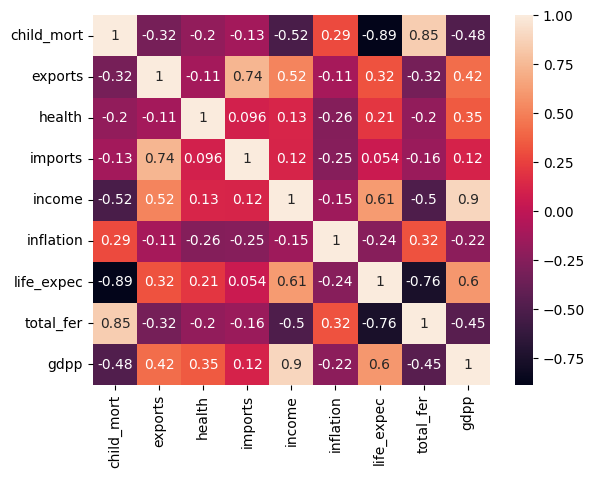

In [8]:
sns.heatmap(df.corr(numeric_only=True),annot = True)
plt.show()

In [9]:
df2=df.drop('country',axis=1)

columnsss = df2.columns

In [10]:
from sklearn.preprocessing import MinMaxScaler

In [11]:
scaler = MinMaxScaler()
df2 = scaler.fit_transform(df2)

In [12]:
df2 = pd.DataFrame(df2,columns=columnsss)

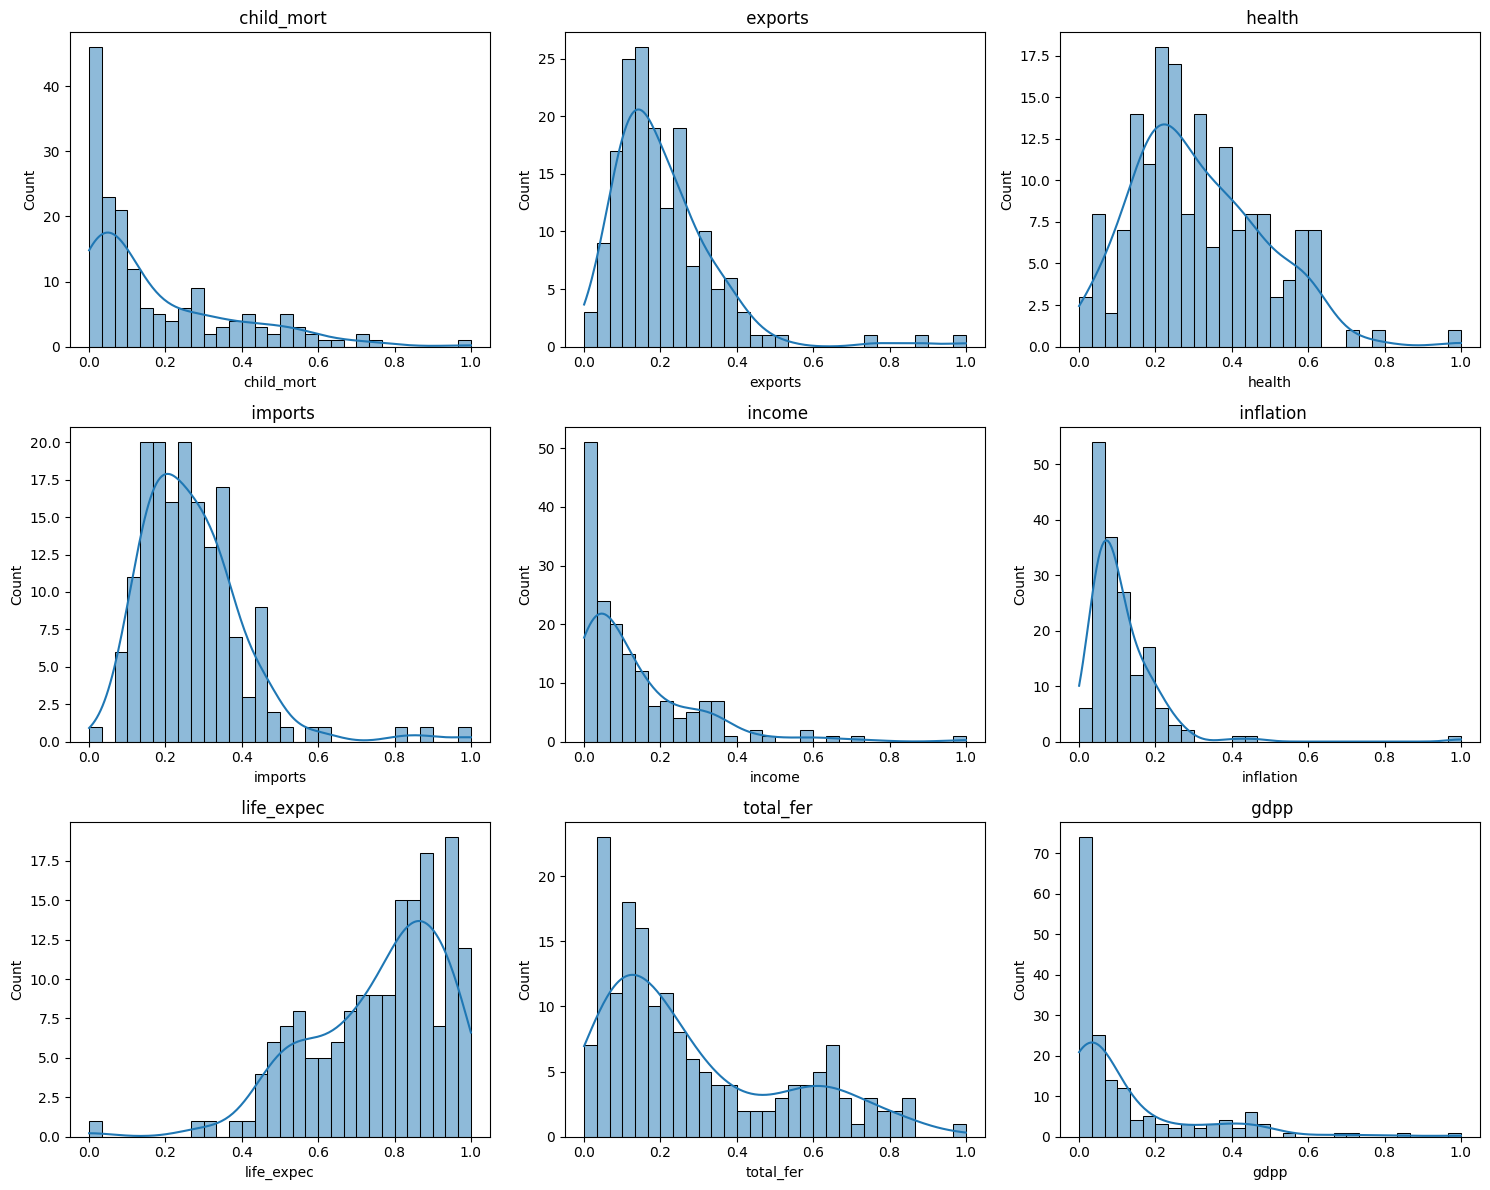

In [13]:
plot_all_hist(df2)

#### **Dimensionality Reduction (PCA): Reducing 9 complex features into principal components to capture the essence of the data without the noise.**

In [14]:
from sklearn.decomposition import PCA

In [15]:
pca = PCA()


In [16]:
pca.fit_transform(df2)

array([[ 0.59907764,  0.09549001,  0.15755381, ..., -0.07680289,
        -0.04060966,  0.02357182],
       [-0.1584743 , -0.2120924 , -0.064189  , ...,  0.04356663,
        -0.03084184,  0.02983267],
       [-0.00368552, -0.13586725, -0.13418203, ...,  0.0456037 ,
         0.01019769,  0.00301172],
       ...,
       [-0.11551228, -0.03203381, -0.19524301, ...,  0.03974308,
         0.00612366, -0.01777991],
       [ 0.33296825, -0.0198243 , -0.02998903, ..., -0.01251879,
        -0.01423106, -0.01144062],
       [ 0.57389669,  0.10878814,  0.03255232, ..., -0.13741331,
         0.05371468, -0.0659275 ]])

In [17]:
pca_df2 = pd.DataFrame(pca.fit_transform(df2))

In [18]:
pca.explained_variance_

array([0.14180615, 0.03450913, 0.03171502, 0.02513534, 0.00974048,
       0.00776992, 0.00306922, 0.00228894, 0.00178941])

In [19]:
pca.explained_variance_ratio_

array([0.55001227, 0.13384784, 0.12301053, 0.09749047, 0.03777964,
       0.03013659, 0.01190434, 0.00887791, 0.00694042])

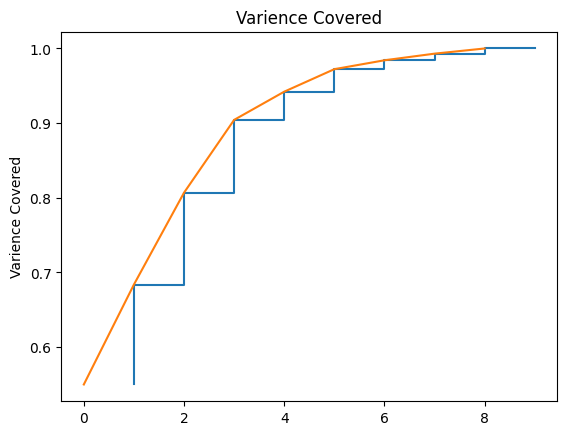

In [20]:
plt.step(list(range(1,10)),np.cumsum(pca.explained_variance_ratio_))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.ylabel('Varience Covered')
plt.title('Varience Covered')
plt.show()

In [21]:
pca_df2 = pca_df2.drop(columns=[3,4,5,6,7,8])

### **K-Means Clustering: Grouping countries into three distinct categories: Direct Aid Needed, Developing, and Stable.**

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [23]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_df2)
    wcss.append(kmeans.inertia_)
    

In [24]:
wcss

[34.533029253081786,
 17.695395368904087,
 11.270622261541497,
 9.280761321292145,
 7.229327464682712,
 6.438653291882461,
 5.19874668809431,
 5.051308101402663,
 4.358806060884984,
 4.253380915277937]

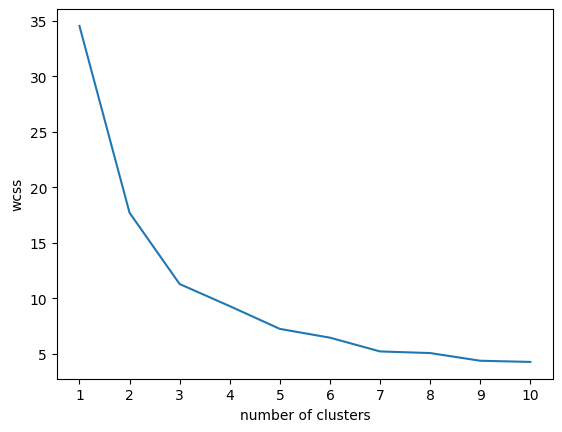

In [25]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel('number of clusters')
plt.ylabel('wcss')
plt.show()


In [26]:
model = KMeans(n_clusters=3)
model.fit(pca_df2)


KMeans(n_clusters=3)

In [27]:
labels = model.labels_

In [28]:
silhouette_score(pca_df2,labels)

np.float64(0.4386320345236685)

In [29]:
df['Class'] = labels

In [30]:
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Class
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2
...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,2
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,2
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,2
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,1


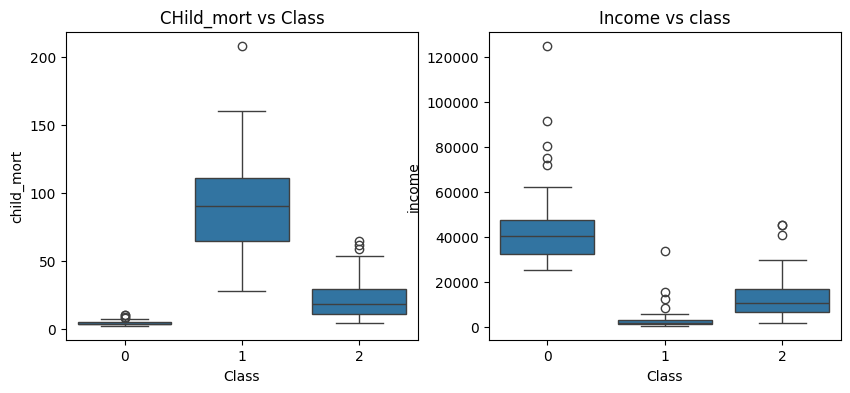

In [31]:
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(data = df, x = 'Class',y='child_mort')
plt.title('CHild_mort vs Class')

plt.subplot(1,2,2)
sns.boxplot(data = df, x = 'Class',y='income')
plt.title('Income vs class')
 
plt.show()

In [32]:
import plotly.express as px

In [33]:
pca_df2.insert(0,column='Country',value=df['country'])

In [34]:
pca_df2['Class']=labels

In [35]:
pca_df2.loc[pca_df2['Class']==1,'Class'] = 'Budget Needed'
pca_df2.loc[pca_df2['Class']==2,'Class'] = 'In Between'
pca_df2.loc[pca_df2['Class']==0,'Class'] = 'No Budget Needed'




/tmp/ipykernel_24/205165502.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Budget Needed' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  pca_df2.loc[pca_df2['Class']==1,'Class'] = 'Budget Needed'


### **Geospatial Visualization**

In [36]:
fig = px.choropleth(
    pca_df2[['Country','Class']],
    locationmode='country names',
    locations='Country',
    title = 'Needed Budget by Country',
    color = pca_df2['Class'],
    color_discrete_map={
        'Budget Needed':'Red',
        'In Betweek':'Yellow',
        'No Budget Needed':'Green'
    }
)

fig.update_geos(fitbounds = 'locations',visible = True)
fig.show()